In [2]:
# =====================================================
# Construct patient-level metabolomics matrix
# - transpose metabolomics table
# - retain tp1 samples
# - generate patient IDs
# =====================================================

In [3]:
import pandas as pd

metabolomics = pd.read_csv("C:/Users/rohan/OneDrive/Desktop/ME-CFS/data/metabolomics/Metabolomics_maaslined_norun.csv")

In [4]:
# 1. metabolomics: rows = samples, columns = metabolites
metab = metabolomics.set_index(metabolomics.columns[0]).T.reset_index()
metab = metab.rename(columns={"index": "sample_id"})

# 2. keep timepoint 1 only
metab_tp1 = metab[metab["sample_id"].str.contains("_tp1", na=False)].copy().reset_index()

# 3. create patient_id to match metadata
metab_tp1["patient_id"] = metab_tp1["sample_id"].replace(r"_tp\d+$", "", regex=True)

cols = ["patient_id"] + [col for col in metab_tp1.columns if col != "patient_id"]
metab_tp1 = metab_tp1[cols]

# 4. inspect before merging
# print(metab_tp1.shape)
# metab_tp1.head()

In [5]:
import pandas as pd

meta = pd.read_csv("C:/Users/rohan/OneDrive/Desktop/ME-CFS/data/metadata/Metadata_061523.csv")
# print(meta)

new_meta = meta.groupby("sample_id_tp1").first().reset_index()

# print(new_meta.head())

In [6]:
master_df = new_meta.merge(
    metab_tp1,
    left_on="sample_id_tp1",
    right_on="patient_id",
    how="inner"
)

master_df = master_df.rename(columns={'sample_id_tp1': 'Patient ID', 'Unnamed: 0': 'Timepoint ID','samples_id' : 'Sample ID', 'timepoints' : 'timepoint', 'study_ptorhc' : 'disease'})
master_df = master_df.drop(columns=["patient_id", "index", "sample_id"])

# print(master_df.shape)
# master_df.head()
# print(master_df.columns[20:30])

In [7]:
metadata_cols = [
    "Patient ID",
    "Timepoint ID",
    "Sample ID",
    "timepoint",
    "disease",
    "illness_duration",
    "age",
    "age_group",
    "gender",
    "bmi",
    "ethnic",
    "race",
    "diet_meat",
    "diet_sugar",
    "diet_veg",
    "diet_grains",
    "diet_fruit",
    "antifungals",
    "antibiotics",
    "probiotics",
    "antivirals",
    "IBS"
]

metabolite_cols = ["Patient ID"] + ["Timepoint ID"] + ["Sample ID"] + ["timepoint"] + ["disease"] + [
    col for col in master_df.columns
    if col not in metadata_cols and col != "Patient ID"
]

metadata_df = master_df[metadata_cols].copy()

metabolomics_df = master_df[metabolite_cols].copy()

In [8]:
mecfs_df = master_df[master_df["disease"] == "MECFS"].copy().reset_index(drop="True")
print(mecfs_df["disease"]) 
print(master_df["disease"].value_counts())

0      MECFS
1      MECFS
2      MECFS
3      MECFS
4      MECFS
       ...  
131    MECFS
132    MECFS
133    MECFS
134    MECFS
135    MECFS
Name: disease, Length: 136, dtype: object
MECFS      136
Control     79
Name: disease, dtype: int64


In [9]:
metabolomics_mecfs_df = metabolomics_df[metabolomics_df["disease"] == "MECFS"].copy().reset_index(drop="True")

X = metabolomics_mecfs_df.drop(columns=[
    "Patient ID",
    "Timepoint ID",
    "Sample ID",
    "timepoint",
    "disease"
])

X

,S-1-pyrroline-5-carboxylate,1-methylnicotinamide,alpha-ketoglutarate,3-hydroxyisobutyrate,3-hydroxy-3-methylglutarate,cholate,4-hydroxyphenylacetate,"5,6-dihydrothymine","9,10-DiHOME",linoleate (18:2n6),...,X-25271,X-25279,X-25343,X-25371,X-25420,X-25422,X-25519,X-25520,X-25810,X-25957
0,1.228548,2.210019,0.507328,1.314349,1.316277,1.211104,0.903310,1.697459,1.457779,0.934828,...,0.129045,58.651307,0.575044,1.673736,0.700329,0.777648,0.401576,3.294835,0.243865,0.802087
1,0.733745,0.382365,0.847127,0.442159,0.784203,0.431694,0.139780,1.268506,0.339513,0.440198,...,0.150920,0.206715,0.484117,3.020528,0.160009,0.665777,0.137405,1.511017,0.105171,0.863240
2,0.818902,12.810497,0.533263,1.404513,1.068380,0.260178,1.167564,0.569123,1.518830,1.000143,...,0.423635,0.113621,0.446355,1.173708,0.145427,0.447486,0.334084,0.427961,0.163105,1.642708
3,1.179346,1.004064,0.465098,0.125369,1.182234,0.157165,0.656423,1.253658,0.290803,0.274124,...,1.150346,0.263747,0.522799,1.256994,0.300740,2.343019,0.324489,1.213484,0.324745,1.024728
4,1.094589,0.796709,0.493174,1.223539,1.244323,0.166239,0.334425,1.250735,0.413015,1.082245,...,0.054587,0.113621,0.459064,1.048394,0.292451,1.867122,0.313803,1.170353,0.107872,0.800934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,0.821089,0.791852,0.329235,0.512337,0.819748,0.108360,0.478362,1.430944,0.187396,0.711487,...,0.491708,0.113621,2.316623,1.516198,0.166144,0.398244,0.149681,1.034829,0.153157,0.925429
132,0.915648,5.401911,0.244785,1.171315,1.049535,0.351848,0.773676,0.906351,0.290212,1.875609,...,0.655270,0.113621,1.656407,1.794405,0.339708,0.965268,0.620606,1.442383,0.189077,0.522738
133,1.022061,3.481481,0.439377,0.072016,0.979909,0.056079,0.254528,1.570966,0.282481,1.879895,...,1.238972,0.113621,1.576765,0.910592,0.361267,0.789558,0.421700,0.781964,0.278026,0.727356
134,2.068860,1.719788,0.261398,0.520849,0.834431,0.434915,0.431116,0.993233,0.269555,0.801951,...,0.015441,0.113621,1.945827,1.547018,0.706108,0.539923,0.577660,0.551042,0.117174,1.349414


In [10]:
X.dtypes.value_counts()

float64    876
dtype: int64

In [11]:
X.isna().sum().sum()

0

In [12]:
constant_cols = X.columns[X.nunique() == 1]
X = X.drop(columns=constant_cols)
(X.nunique() == 1).sum()

0

In [13]:
# =====================================================
# Preprocessing for Subtype Discovery
# =====================================================

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,S-1-pyrroline-5-carboxylate,1-methylnicotinamide,alpha-ketoglutarate,3-hydroxyisobutyrate,3-hydroxy-3-methylglutarate,cholate,4-hydroxyphenylacetate,"5,6-dihydrothymine","9,10-DiHOME",linoleate (18:2n6),...,X-25271,X-25279,X-25343,X-25371,X-25420,X-25422,X-25519,X-25520,X-25810,X-25957
0,0.244513,0.243421,1.011979,0.819459,0.208982,0.848677,0.779460,1.401026,3.691049,0.094071,...,-0.240090,2.313437,-0.346252,-0.033604,1.023489,-0.498388,0.338646,2.296532,0.266998,-0.242928
1,-1.038880,-0.535530,4.225898,-0.703454,-1.045891,-0.074440,-1.056084,0.006055,-0.308782,-1.197265,...,-0.233914,-0.219942,-0.518753,2.008108,-1.136313,-0.646196,-0.873424,0.378415,-0.675858,-0.033483
2,-0.818004,4.761376,1.257284,0.976892,-0.375672,-0.277580,1.414732,-2.268366,3.909417,0.264589,...,-0.156912,-0.223977,-0.590392,-0.791636,-1.194602,-0.934610,0.028978,-0.786182,-0.282016,2.636142
3,0.116897,-0.270561,0.612555,-1.256593,-0.107153,-0.399588,0.185939,-0.042233,-0.483008,-1.630835,...,0.048277,-0.217470,-0.445368,-0.665376,-0.573773,1.569841,-0.015045,0.058481,0.816830,0.519602
4,-0.102942,-0.358936,0.878108,0.660897,0.039283,-0.388840,-0.588154,-0.051737,-0.045878,0.478935,...,-0.261113,-0.223977,-0.566282,-0.981610,-0.606905,0.941068,-0.064075,0.012104,-0.657493,-0.246878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,-0.812332,-0.361006,-0.672473,-0.580917,-0.962060,-0.457391,-0.242124,0.534311,-0.852878,-0.489007,...,-0.137691,-0.223977,2.957749,-0.272428,-1.111791,-0.999671,-0.817099,-0.133624,-0.349641,0.179511
132,-0.567069,1.603815,-1.471224,0.569710,-0.420117,-0.169008,0.467818,-1.171687,-0.485124,2.550177,...,-0.091509,-0.223977,1.705234,0.149328,-0.418008,-0.250497,1.343596,0.304614,-0.105457,-1.199680
133,-0.291061,0.785322,0.369282,-1.349753,-0.584327,-0.519311,-0.780228,0.989667,-0.512775,2.561366,...,0.073300,-0.223977,1.554142,-1.190514,-0.331832,-0.482652,0.430978,-0.405526,0.499233,-0.498875
134,2.424069,0.034483,-1.314097,-0.566055,-0.927431,-0.070626,-0.355706,-0.889143,-0.559008,-0.252834,...,-0.272166,-0.223977,2.254300,-0.225705,1.046592,-0.812480,1.146553,-0.653834,-0.594260,1.631628


In [15]:
X_scaled.mean().mean()

2.820339666757856e-18

In [16]:
X_scaled.std().mean()

1.0036968702787747

In [17]:
# =====================================================
# Dimensionality Reduction: PCA
# =====================================================

In [18]:
from sklearn.decomposition import PCA

In [19]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [20]:
X_pca.shape

(136, 136)

In [21]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance[:10])

[0.07623007 0.06248293 0.04674564 0.04026118 0.03678066 0.03025414
 0.02589903 0.02350945 0.02254184 0.02082143]


In [22]:
import numpy as np

cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance[:20])

[0.07623007 0.138713   0.18545864 0.22571982 0.26250049 0.29275463
 0.31865365 0.3421631  0.36470494 0.38552637 0.40461506 0.42248153
 0.43893859 0.45506105 0.470849   0.48609592 0.50049548 0.51319704
 0.52578799 0.53798023]


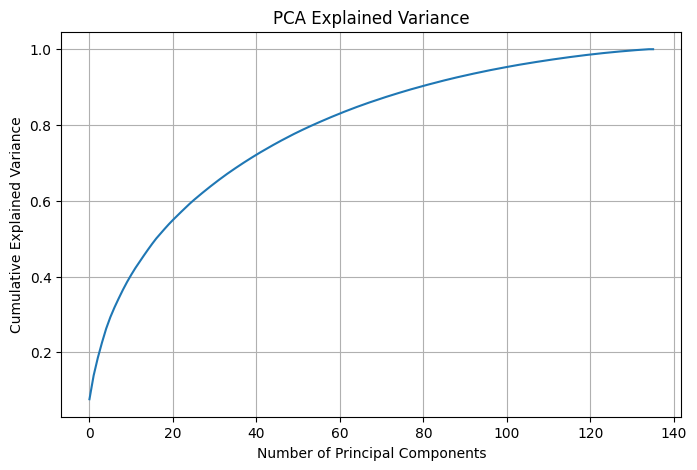

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(cumulative_variance)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

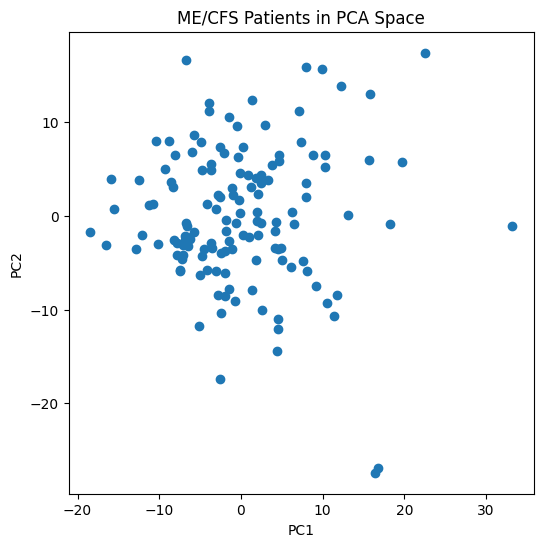

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("ME/CFS Patients in PCA Space")

plt.show()

In [25]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns
)

print(loadings.head())

                                  0         1         2         3         4    \
S-1-pyrroline-5-carboxylate -0.004094  0.053764  0.033723 -0.007443 -0.013092   
1-methylnicotinamide         0.001075  0.020132 -0.003237 -0.016052 -0.017068   
alpha-ketoglutarate          0.032688  0.010292  0.000888 -0.021351 -0.024944   
3-hydroxyisobutyrate         0.029998 -0.011636  0.019212 -0.011425 -0.041735   
3-hydroxy-3-methylglutarate  0.035368  0.030418  0.002651 -0.026946 -0.000002   

                                  5         6         7         8         9    \
S-1-pyrroline-5-carboxylate  0.004650  0.021317 -0.045713 -0.005494  0.012373   
1-methylnicotinamide         0.038780 -0.074766  0.011138 -0.072011 -0.035831   
alpha-ketoglutarate          0.015310 -0.039167  0.077274  0.008756 -0.023017   
3-hydroxyisobutyrate        -0.013612 -0.020761  0.001503 -0.024502  0.032206   
3-hydroxy-3-methylglutarate  0.008685 -0.036153  0.046647  0.000750 -0.027759   

                          

In [26]:
pc1_loadings = loadings[0]

pc1_loadings = pc1_loadings.sort_values(
    key=abs,
    ascending=False
)

print(pc1_loadings.head(20))

palmitoylcarnitine (C16)                       0.090272
C-glycosyltryptophan                           0.085275
stearoyl ethanolamide                          0.085199
palmitoleoylcarnitine (C16:1)*                 0.082487
myristoylcarnitine (C14)                       0.079888
N-acetylalanine                                0.079545
hydroxyasparagine**                            0.077748
5-dodecenoylcarnitine (C12:1)                  0.076501
myristoleoylcarnitine (C14:1)*                 0.076276
heptenedioate (C7:1-DC)*                       0.076070
gamma-glutamylisoleucine*                      0.074192
N-stearoyl-sphinganine (d18:0/18:0)*           0.074063
3-hydroxyoleoylcarnitine                       0.073924
3-hydroxy-2-ethylpropionate                    0.073905
laurylcarnitine (C12)                          0.071995
palmitate (16:0)                               0.071827
aconitate [cis or trans]                       0.071372
N-acetyltaurine                                0

In [27]:
pc_scores = pd.DataFrame(
    X_pca,
    index=mecfs_df.index
)

print(pc_scores[0].describe())

count    1.360000e+02
mean    -3.134747e-16
std      8.197280e+00
min     -1.852254e+01
25%     -5.705057e+00
50%     -1.127635e+00
75%      4.522198e+00
max      3.322006e+01
Name: 0, dtype: float64


In [28]:
# =====================================================
# Clustering: K-Means
# =====================================================

In [29]:
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(n_components_80)

55


In [30]:
X_cluster = X_pca[:, :n_components_80]

print(X_cluster.shape)

(136, 55)


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_cluster)

    inertia.append(model.inertia_)
    silhouette.append(
        silhouette_score(X_cluster, labels)
    )

In [32]:
silhouette

[0.09609862705997442,
 0.03478139120197909,
 0.04259830215249399,
 0.02351541093100235,
 0.02640819041326296,
 0.024379171538949133,
 0.035009230472264584,
 0.013702644480333355,
 0.024428538080506424]

In [33]:
inertia

[89759.07773857462,
 85885.89184955182,
 83120.21934699529,
 82001.01551123116,
 79363.10570657444,
 76009.91352184863,
 75272.28465012716,
 73342.6430370892,
 72105.5598887608]

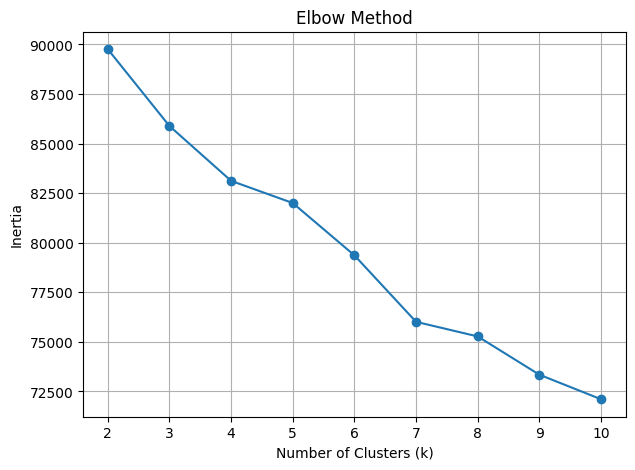

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

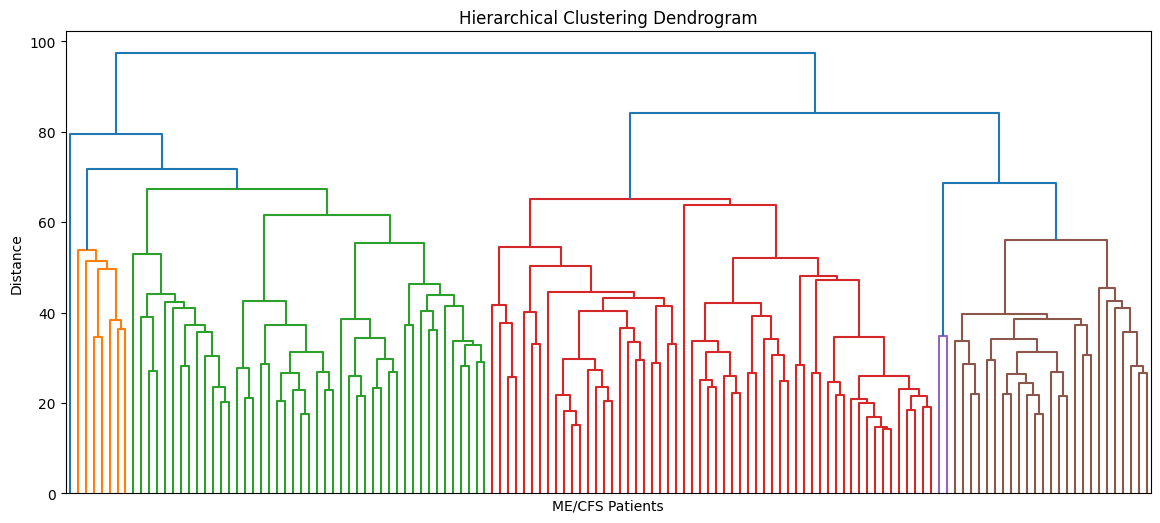

    k  silhouette_score                                      cluster_sizes
0   2          0.056683                                     {1: 53, 2: 83}
1   3          0.030846                              {1: 53, 2: 56, 3: 27}
2   4          0.035190                        {1: 52, 2: 1, 3: 56, 4: 27}
3   5          0.038842                  {1: 7, 2: 45, 3: 1, 4: 56, 5: 27}
4   6          0.033566            {1: 7, 2: 45, 3: 1, 4: 56, 5: 2, 6: 25}
5   7          0.036479     {1: 7, 2: 13, 3: 32, 4: 1, 5: 56, 6: 2, 7: 25}
6   8          0.023789  {1: 7, 2: 13, 3: 32, 4: 1, 5: 24, 6: 32, 7: 2,...
7   9          0.017602  {1: 7, 2: 13, 3: 32, 4: 1, 5: 24, 6: 31, 7: 1,...
8  10          0.010405  {1: 7, 2: 13, 3: 13, 4: 19, 5: 1, 6: 24, 7: 31...


In [35]:
# =====================================================
# Clustering: Hierarchical Clustering
# =====================================================

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------------------
# 1. Build hierarchical clustering tree
# -----------------------------------------------------

Z = linkage(
    X_cluster,
    method="ward"
)

# -----------------------------------------------------
# 2. Plot dendrogram
# -----------------------------------------------------

plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    no_labels=True,
    color_threshold=None
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("ME/CFS Patients")
plt.ylabel("Distance")

plt.show()

# -----------------------------------------------------
# 3. Try different numbers of clusters
# -----------------------------------------------------

hierarchical_scores = []

for k in range(2, 11):
    
    labels = fcluster(
        Z,
        t=k,
        criterion="maxclust"
    )
    
    score = silhouette_score(X_cluster, labels)
    
    hierarchical_scores.append({
        "k": k,
        "silhouette_score": score,
        "cluster_sizes": pd.Series(labels).value_counts().sort_index().to_dict()
    })

hierarchical_results = pd.DataFrame(hierarchical_scores)

print(hierarchical_results)

In [36]:
# =====================================================
# Supervised Learning
# ME/CFS vs Control Classification
# =====================================================

# 1. Build X and y
# 2. Train/Test Split
# 3. Baseline Logistic Regression
# 4. Evaluate Performance
# 5. Feature Selection (LASSO)
# 6. Sparse Biomarker Panel

In [37]:
# Use all baseline patients
supervised_df = master_df.copy()

# X = metabolite values
X_all = supervised_df[metabolite_cols].copy().drop(columns=[
    "Patient ID",
    "Timepoint ID",
    "Sample ID",
    "timepoint",
    "disease"
])


# y = disease label
y = supervised_df["disease"].map({
    "MECFS": 1,
    "Control": 0
})

print("X shape:", X_all.shape)
print("y counts:")
print(y.value_counts())

X_all

X shape: (215, 876)
y counts:
1    136
0     79
Name: disease, dtype: int64


,S-1-pyrroline-5-carboxylate,1-methylnicotinamide,alpha-ketoglutarate,3-hydroxyisobutyrate,3-hydroxy-3-methylglutarate,cholate,4-hydroxyphenylacetate,"5,6-dihydrothymine","9,10-DiHOME",linoleate (18:2n6),...,X-25271,X-25279,X-25343,X-25371,X-25420,X-25422,X-25519,X-25520,X-25810,X-25957
0,1.228548,2.210019,0.507328,1.314349,1.316277,1.211104,0.903310,1.697459,1.457779,0.934828,...,0.129045,58.651307,0.575044,1.673736,0.700329,0.777648,0.401576,3.294835,0.243865,0.802087
1,0.733745,0.382365,0.847127,0.442159,0.784203,0.431694,0.139780,1.268506,0.339513,0.440198,...,0.150920,0.206715,0.484117,3.020528,0.160009,0.665777,0.137405,1.511017,0.105171,0.863240
2,0.769434,0.852937,0.452293,2.226022,0.699935,0.204640,0.139780,0.982737,0.189137,1.181614,...,0.245116,0.113621,0.437375,0.771918,0.512418,2.367723,0.363365,2.589373,0.619235,0.600658
3,0.818902,12.810497,0.533263,1.404513,1.068380,0.260178,1.167564,0.569123,1.518830,1.000143,...,0.423635,0.113621,0.446355,1.173708,0.145427,0.447486,0.334084,0.427961,0.163105,1.642708
4,1.592041,1.814795,0.334482,0.411693,1.199848,0.804103,0.680068,1.246592,0.648997,0.764184,...,0.247465,0.113621,0.440257,1.807213,0.167775,1.910401,0.185483,0.632967,0.219057,0.622267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,1.082735,2.272616,0.243889,0.483282,0.769107,0.092958,0.965194,0.997841,0.259342,0.478034,...,0.012949,0.216319,2.079928,1.248418,0.799395,0.618329,0.822006,1.285096,0.204108,0.963445
211,1.093481,1.087127,0.273578,0.463225,0.920955,0.092710,0.898634,2.100988,0.124551,0.726527,...,0.003007,0.113621,2.169599,1.762219,0.268679,0.304149,0.583726,0.672852,0.055616,0.825326
212,0.710380,1.695763,0.183074,0.520475,0.626989,0.240494,1.627615,1.527239,0.167170,0.382255,...,0.142869,0.113621,1.549191,1.516188,0.286678,0.455186,0.377479,5.051718,0.204653,0.805029
213,0.936515,1.506728,0.400178,0.200751,1.053093,0.076210,0.346729,1.417201,0.135192,0.945850,...,0.438019,0.113621,2.607491,2.180546,0.389214,1.905540,0.900775,1.045173,0.228124,0.785686


In [38]:
print("Missing values in X:", X_all.isna().sum().sum())
print("Data types:")
print(X_all.dtypes.value_counts())

print("Missing labels in y:", y.isna().sum())

Missing values in X: 0
Data types:
float64    876
dtype: int64
Missing labels in y: 0


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training set: (172, 876)
Testing set: (43, 876)

Training labels:
1    109
0     63
Name: disease, dtype: int64

Testing labels:
1    27
0    16
Name: disease, dtype: int64


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(172, 876)
(43, 876)


In [41]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

-7.721573430797985e-17
0.9994290607584835


In [42]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [43]:
y_pred = log_reg.predict(X_test_scaled)

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [44]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7209302325581395
AUC: 0.7523148148148148

Confusion matrix:
[[ 9  7]
 [ 5 22]]

Classification report:
              precision    recall  f1-score   support

           0       0.64      0.56      0.60        16
           1       0.76      0.81      0.79        27

    accuracy                           0.72        43
   macro avg       0.70      0.69      0.69        43
weighted avg       0.72      0.72      0.72        43



In [45]:
# =====================================================
# Feature Selection (LASSO)
# =====================================================

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import pandas as pd

lasso_log_reg = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=1000,
    random_state=42
)

lasso_log_reg.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_log_reg.predict(X_test_scaled)
y_prob_lasso = lasso_log_reg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("AUC:", roc_auc_score(y_test, y_prob_lasso))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_lasso))

print("\nClassification report:")
print(classification_report(y_test, y_pred_lasso))

Accuracy:

 0.6511627906976745
AUC: 0.7662037037037037

Confusion matrix:
[[10  6]
 [ 9 18]]

Classification report:
              precision    recall  f1-score   support

           0       0.53      0.62      0.57        16
           1       0.75      0.67      0.71        27

    accuracy                           0.65        43
   macro avg       0.64      0.65      0.64        43
weighted avg       0.67      0.65      0.66        43



In [47]:
lasso_coefs = pd.Series(
    lasso_log_reg.coef_[0],
    index=X_all.columns
)

selected_metabolites = lasso_coefs[lasso_coefs != 0].sort_values(
    key=abs,
    ascending=False
)

print("Number of selected metabolites:", selected_metabolites.shape[0])

print(selected_metabolites)

Number of selected metabolites: 91
3-(4-hydroxyphenyl)lactate                   -1.530956
X-07765                                      -0.697762
X-18886                                       0.690852
2-naphthol sulfate                           -0.685880
cysteine s-sulfate                            0.660509
                                                ...   
glycochenodeoxycholate 3-sulfate              0.012025
X-25172                                      -0.008856
dihomo-linolenoylcarnitine (C20:3n3 or 6)*   -0.003815
3beta-hydroxy-5-cholenoate                   -0.003677
ibuprofen                                    -0.002321
Length: 91, dtype: float64


In [48]:
# =====================================================
# LASSO Strength Sweep
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

C_values = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

lasso_results = []

for C in C_values:
    
    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C,
        max_iter=1000,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    coefs = pd.Series(
        model.coef_[0],
        index=X_all.columns
    )
    
    n_selected = (coefs != 0).sum()
    
    lasso_results.append({
        "C": C,
        "accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "n_selected_metabolites": n_selected
    })

lasso_results_df = pd.DataFrame(lasso_results)

print(lasso_results_df)

      C  accuracy       AUC  n_selected_metabolites
0  1.00  0.651163  0.766204                      91
1  0.50  0.651163  0.766204                      81
2  0.20  0.674419  0.745370                      54
3  0.10  0.720930  0.726852                      31
4  0.05  0.697674  0.706019                       6
5  0.02  0.372093  0.500000                       0
6  0.01  0.372093  0.500000                       0


In [49]:
model_6 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.06,
    max_iter=1000,
    random_state=42
)

model_6.fit(X_train_scaled, y_train)

coefs_6 = pd.Series(
    model_6.coef_[0],
    index=X_all.columns
)

selected_6 = coefs_6[coefs_6 != 0].sort_values(
    key=abs,
    ascending=False
)

print(selected_6)

3-(4-hydroxyphenyl)lactate                     -0.241806
N-acetylglutamate                               0.175852
N-palmitoyl-sphingosine (d18:1/16:0)            0.088955
N-palmitoyl-sphinganine (d18:0/16:0)            0.062750
X-21258                                        -0.056765
1-stearoyl-2-oleoyl-GPC (18:0/18:1)             0.047758
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.042264
trigonelline (N'-methylnicotinate)             -0.032481
X-23780                                        -0.013772
glycodeoxycholate 3-sulfate                     0.007544
dtype: float64


In [50]:
selected_6.index.tolist()

['3-(4-hydroxyphenyl)lactate',
 'N-acetylglutamate',
 'N-palmitoyl-sphingosine (d18:1/16:0)',
 'N-palmitoyl-sphinganine (d18:0/16:0)',
 'X-21258',
 '1-stearoyl-2-oleoyl-GPC (18:0/18:1)',
 '1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)',
 "trigonelline (N'-methylnicotinate)",
 'X-23780',
 'glycodeoxycholate 3-sulfate']

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

lasso_cv = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.06,
    max_iter=1000,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

auc_scores = cross_val_score(
    lasso_cv,
    X_all,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:")
print(auc_scores)

print("\nMean AUC:")
print(auc_scores.mean())

print("\nStd AUC:")
print(auc_scores.std())

Fold AUCs:
[0.7452381  0.77777778 0.80787037 0.79398148 0.71064815]

Mean AUC:
0.7671031746031746

Std AUC:
0.03511013099371605


In [52]:
# =====================================================
# Rigorous Cross-Validation with Pipeline
# =====================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.06,
        max_iter=1000,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

auc_scores_pipeline = cross_val_score(
    lasso_pipeline,
    X_all,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:")
print(auc_scores_pipeline)

print("\nMean AUC:")
print(auc_scores_pipeline.mean())

print("\nStd AUC:")
print(auc_scores_pipeline.std())

Fold AUCs:
[0.72857143 0.78472222 0.70833333 0.78009259 0.83796296]

Mean AUC:
0.767936507936508

Std AUC:
0.04568453326458566


In [53]:
# =====================================================
# LASSO Hyperparameter Tuning
# =====================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np

C_values = np.round(np.arange(0.03, 0.151, 0.01), 2)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tuning_results = []

for C in C_values:
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=C,
            max_iter=1000,
            random_state=42
        ))
    ])
    
    auc_scores = cross_val_score(
        pipeline,
        X_all,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    pipeline.fit(X_all, y)
    
    coefs = pipeline.named_steps["lasso"].coef_[0]
    n_selected = (coefs != 0).sum()
    
    tuning_results.append({
        "C": C,
        "mean_auc": auc_scores.mean(),
        "std_auc": auc_scores.std(),
        "n_metabolites": n_selected
    })

tuning_df = pd.DataFrame(tuning_results)

tuning_df.sort_values("mean_auc", ascending=False)

,C,mean_auc,std_auc,n_metabolites
12,0.15,0.801389,0.022222,61
11,0.14,0.798122,0.019458,57
8,0.11,0.797050,0.010004,44
9,0.12,0.796680,0.012225,50
10,0.13,0.796257,0.016685,56
7,0.10,0.790529,0.016921,36
5,0.08,0.788929,0.028957,26
6,0.09,0.788082,0.025261,32
4,0.07,0.780013,0.031375,21
3,0.06,0.767937,0.045685,16


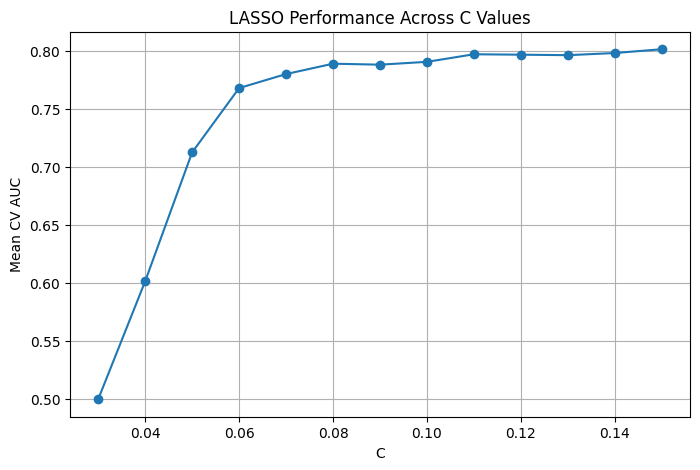

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(tuning_df["C"], tuning_df["mean_auc"], marker="o")

plt.xlabel("C")
plt.ylabel("Mean CV AUC")
plt.title("LASSO Performance Across C Values")
plt.grid(True)

plt.show()

In [55]:
# =====================================================
# Elastic Net Grid Search
# =====================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

C_values = [0.05, 0.1, 0.15, 0.2]
l1_ratios = [0.2, 0.5, 0.8]

elastic_results = []

for C in C_values:
    for l1_ratio in l1_ratios:
        
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("elastic", LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                C=C,
                l1_ratio=l1_ratio,
                max_iter=5000,
                random_state=42
            ))
        ])
        
        auc_scores = cross_val_score(
            pipeline,
            X_all,
            y,
            cv=cv,
            scoring="roc_auc"
        )
        
        # Fit once on the full dataset just to count selected metabolites
        pipeline.fit(X_all, y)
        
        coefs = pipeline.named_steps["elastic"].coef_[0]
        n_selected = (coefs != 0).sum()
        
        elastic_results.append({
            "C": C,
            "l1_ratio": l1_ratio,
            "mean_auc": auc_scores.mean(),
            "std_auc": auc_scores.std(),
            "n_metabolites": n_selected
        })

elastic_results_df = pd.DataFrame(elastic_results)

elastic_results_df.sort_values("mean_auc", ascending=False)

KeyboardInterrupt: 

In [56]:
best_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=0.1,
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    ))
])

best_elastic.fit(X_all, y)

elastic_coefs = pd.Series(
    best_elastic.named_steps["elastic"].coef_[0],
    index=X_all.columns
)

selected_elastic = elastic_coefs[elastic_coefs != 0].sort_values(
    key=abs,
    ascending=False
)

print("Number selected:", selected_elastic.shape[0])
print(selected_elastic)

Number selected: 98
3-(4-hydroxyphenyl)lactate                   -0.403463
vanillylmandelate (VMA)                      -0.355827
N4-acetylcytidine                             0.351415
N-acetylglutamate                             0.271151
X-11852                                      -0.240374
                                                ...   
3-ureidopropionate                           -0.004496
(16 or 17)-methylstearate (a19:0 or i19:0)   -0.002568
X-24748                                       0.001531
tartarate                                     0.000548
S-adenosylhomocysteine (SAH)                  0.000533
Length: 98, dtype: float64


In [57]:
# RANDOM FOREST

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_auc = cross_val_score(
    rf,
    X_all,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:")
print(rf_auc)

print("\nMean AUC:")
print(rf_auc.mean())

print("\nStd AUC:")
print(rf_auc.std())

Fold AUCs:
[0.82619048 0.85532407 0.76157407 0.72453704 0.66087963]

Mean AUC:
0.7657010582010582

Std AUC:
0.06984310300524292


In [59]:
rf.fit(X_all, y)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_all.columns
)

top_rf = rf_importance.sort_values(
    ascending=False
)

print(top_rf.head(30))

N-acetylglutamate                                                      0.012712
3-(4-hydroxyphenyl)lactate                                             0.010576
X-11849                                                                0.008731
X-11847                                                                0.008116
X-11795                                                                0.007009
vanillylmandelate (VMA)                                                0.006696
p-cresol glucuronide*                                                  0.006589
3-hydroxyadipate                                                       0.006140
N4-acetylcytidine                                                      0.005806
N-palmitoyl-sphinganine (d18:0/16:0)                                   0.005798
X-21442                                                                0.005775
phenyllactate (PLA)                                                    0.005488
alpha-hydroxyisovalerate                

In [60]:
lasso_features = selected_6.index.tolist()  # or selected_9 if using C=0.06

In [61]:
rf_top20 = top_rf.head(20).index.tolist()

overlap = set(lasso_features).intersection(rf_top20)

print("Overlap:")
print(overlap)
print("\nNumber overlapping:", len(overlap))

Overlap:
{'N-acetylglutamate', '1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)', 'N-palmitoyl-sphinganine (d18:0/16:0)', 'N-palmitoyl-sphingosine (d18:1/16:0)', '3-(4-hydroxyphenyl)lactate'}

Number overlapping: 5


In [62]:
consensus_features = list(overlap)

X_consensus = X_all[consensus_features]

print(X_consensus.shape)

(215, 5)


In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

auc_scores = cross_val_score(
    pipeline,
    X_consensus,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:")
print(auc_scores)

print("\nMean AUC:")
print(auc_scores.mean())

print("\nStd AUC:")
print(auc_scores.std())

Fold AUCs:
[0.75952381 0.82407407 0.78703704 0.80092593 0.78240741]

Mean AUC:
0.7907936507936508

Std AUC:
0.021318976388049322


In [64]:
consensus_features = [
    "N-acetylglutamate",
    "3-(4-hydroxyphenyl)lactate",
    "N-palmitoyl-sphingosine (d18:1/16:0)",
    "N-palmitoyl-sphinganine (d18:0/16:0)",
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)"
]

X_consensus = X_all[consensus_features]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

aucs = cross_val_score(
    pipe,
    X_consensus,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:")
print(aucs)

print("\nMean AUC:")
print(aucs.mean())

print("\nStd:")
print(aucs.std())

Fold AUCs:
[0.75952381 0.82407407 0.78703704 0.80092593 0.78240741]

Mean AUC:
0.7907936507936508

Std:
0.021318976388049322


In [65]:
pipe.fit(X_consensus, y)

coef_df = pd.DataFrame({
    "Metabolite": X_consensus.columns,
    "Coefficient": pipe.named_steps["clf"].coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

coef_df

,Metabolite,Coefficient,Abs_Coefficient
1,3-(4-hydroxyphenyl)lactate,-0.874385,0.874385
0,N-acetylglutamate,0.640948,0.640948
2,N-palmitoyl-sphingosine (d18:1/16:0),0.523680,0.523680
4,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.440468,0.440468
3,N-palmitoyl-sphinganine (d18:0/16:0),0.264397,0.264397


In [66]:
summary = X_consensus.copy()
summary["ME_CFS"] = y.values

summary.groupby("ME_CFS")[consensus_features].mean().T

ME_CFS,0,1
N-acetylglutamate,0.464753,0.592174
3-(4-hydroxyphenyl)lactate,1.018901,0.832083
N-palmitoyl-sphingosine (d18:1/16:0),1.132769,1.336100
N-palmitoyl-sphinganine (d18:0/16:0),1.033346,1.310974
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),1.145679,1.444259


In [67]:
from scipy.stats import ttest_ind
import pandas as pd

results = []

for m in consensus_features:

    ctrl = mecfs_df.loc[y == 0, m]
    case = mecfs_df.loc[y == 1, m]

    t, p = ttest_ind(case, ctrl)

    results.append([m, p])

pd.DataFrame(
    results,
    columns=["Metabolite", "p_value"]
).sort_values("p_value")

,Metabolite,p_value
4,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.201078
1,3-(4-hydroxyphenyl)lactate,0.238921
0,N-acetylglutamate,0.303230
3,N-palmitoyl-sphinganine (d18:0/16:0),0.355254
2,N-palmitoyl-sphingosine (d18:1/16:0),0.730065


In [68]:
for m in consensus_features:
    print("\n", m)
    print(mecfs_df.groupby(y)[m].describe()[["mean","std"]])


 N-acetylglutamate
             mean       std
disease                    
0        0.615348  0.184177
1        0.582173  0.166227

 3-(4-hydroxyphenyl)lactate
             mean       std
disease                    
0        0.880201  0.376755
1        0.811316  0.279348

 N-palmitoyl-sphingosine (d18:1/16:0)
             mean       std
disease                    
0        1.352245  0.395488
1        1.329132  0.340417

 N-palmitoyl-sphinganine (d18:0/16:0)
             mean       std
disease                    
0        1.374636  0.558956
1        1.283499  0.510993

 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
             mean       std
disease                    
0        1.351273  0.573313
1        1.484391  0.546267


In [69]:
import numpy as np

for m in consensus_features:

    ctrl = mecfs_df.loc[y == 0, m]
    case = mecfs_df.loc[y == 1, m]

    pooled_sd = np.sqrt(
        ((ctrl.std()**2) + (case.std()**2)) / 2
    )

    d = (case.mean() - ctrl.mean()) / pooled_sd

    print(m, round(d, 3))

N-acetylglutamate -0.189
3-(4-hydroxyphenyl)lactate -0.208
N-palmitoyl-sphingosine (d18:1/16:0) -0.063
N-palmitoyl-sphinganine (d18:0/16:0) -0.17
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6) 0.238


In [70]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

for m in consensus_features:

    X_single = X_all[[m]]

    auc = cross_val_score(
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression())
        ]),
        X_single,
        y,
        cv=5,
        scoring="roc_auc"
    ).mean()

    print(m, round(auc, 3))

N-acetylglutamate 0.641
3-(4-hydroxyphenyl)lactate 0.693
N-palmitoyl-sphingosine (d18:1/16:0) 0.683
N-palmitoyl-sphinganine (d18:0/16:0) 0.66
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6) 0.675


In [71]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
import numpy as np

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_select",
     SelectFromModel(
         LogisticRegression(
             penalty="l1",
             solver="liblinear",
             C=0.06,
             max_iter=5000
         )
     )),
    ("clf", LogisticRegression(max_iter=5000))
])

aucs = cross_val_score(
    pipe,
    X_all,
    y,
    cv=outer_cv,
    scoring="roc_auc"
)

print("Fold AUCs:")
print(np.round(aucs, 3))

print("\nMean AUC:")
print(round(aucs.mean(), 3))

print("\nStd:")
print(round(aucs.std(), 3))

Fold AUCs:
[0.748 0.799 0.738 0.762 0.796]

Mean AUC:
0.769

Std:
0.025


In [72]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
import numpy as np
from collections import Counter

feature_counter = Counter()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

aucs = []
n_features = []

for train_idx, test_idx in cv.split(X_all, y):

    X_train = X_all.iloc[train_idx]
    X_test = X_all.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    lasso = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.06,
        max_iter=5000
    )

    selector = SelectFromModel(lasso)
    selector.fit(X_train_s, y_train)

    X_train_sel = selector.transform(X_train_s)
    X_test_sel = selector.transform(X_test_s)

    n_features.append(X_train_sel.shape[1])

    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_train_sel, y_train)

    auc = roc_auc_score(
        y_test,
        clf.predict_proba(X_test_sel)[:, 1]
    )

    aucs.append(auc)
    
    selected = X_all.columns[selector.get_support()]
    
    selector.fit(X_train_s, y_train)

    selected = X_all.columns[selector.get_support()]

    feature_counter.update(selected)

print("Mean AUC:", np.mean(aucs))
print(feature_counter.most_common(30))
print("Mean features selected:", np.mean(n_features))

Mean AUC: 0.7685052910052911
[('3-(4-hydroxyphenyl)lactate', 5), ('N-acetylglutamate', 5), ('N4-acetylcytidine', 5), ('1-methylurate', 4), ('1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)', 4), ('N-palmitoyl-sphingosine (d18:1/16:0)', 4), ('vanillylmandelate (VMA)', 3), ('sphingomyelin (d18:1/24:1, d18:2/24:0)*', 3), ('phenyllactate (PLA)', 2), ('beta-cryptoxanthin', 2), ('p-cresol glucuronide*', 2), ('glycodeoxycholate 3-sulfate', 2), ('branched-chain, straight-chain, or cyclopropyl 10:1 fatty acid (1)*', 2), ("trigonelline (N'-methylnicotinate)", 2), ('1-palmitoyl-2-docosahexaenoyl-GPC (16:0/22:6)', 2), ('N-palmitoyl-sphinganine (d18:0/16:0)', 1), ('10-undecenoate (11:1n1)', 1), ('gulonate*', 1), ('carotene diol (3)', 1), ('cysteine s-sulfate', 1), ('N-acetylhistidine', 1), ('N-acetyltaurine', 1), ('sphingomyelin (d18:2/21:0, d16:2/23:0)*', 1), ('1-(1-enyl-palmitoyl)-2-linoleoyl-GPE (P-16:0/18:2)*', 1), ('linolenoylcarnitine (C18:3)*', 1), ('X-14939', 1), ('X-25172', 1), ("2'-deoxyurid

In [73]:
core_features = [
    "3-(4-hydroxyphenyl)lactate",
    "N-acetylglutamate",
    "N4-acetylcytidine",
    "1-methylurate",
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)",
    "N-palmitoyl-sphingosine (d18:1/16:0)"
]

X_core = X_all[core_features]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

aucs = cross_val_score(
    pipe,
    X_core,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:")
print(aucs)

print("\nMean AUC:")
print(aucs.mean())

print("\nStd:")
print(aucs.std())

Fold AUCs:
[0.73095238 0.89814815 0.83796296 0.84027778 0.85648148]

Mean AUC:
0.8327645502645502

Std:
0.055293214051727956


In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_scaled = StandardScaler().fit_transform(X_all)

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.06,
    max_iter=5000
)

lasso.fit(X_scaled, y)

selected = pd.DataFrame({
    "Metabolite": X_all.columns,
    "Coefficient": lasso.coef_[0]
})

selected = selected[selected["Coefficient"] != 0]
selected["Abs"] = selected["Coefficient"].abs()

selected.sort_values("Abs", ascending=False)

,Metabolite,Coefficient,Abs
20,3-(4-hydroxyphenyl)lactate,-0.226213,0.226213
138,N-acetylglutamate,0.223095,0.223095
259,N4-acetylcytidine,0.162369,0.162369
107,N-palmitoyl-sphingosine (d18:1/16:0),0.145522,0.145522
516,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.121262,0.121262
85,vanillylmandelate (VMA),-0.099668,0.099668
465,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",0.094198,0.094198
254,1-methylurate,-0.082832,0.082832
716,"branched-chain, straight-chain, or cyclopropyl...",-0.058953,0.058953
482,p-cresol glucuronide*,0.045653,0.045653


In [75]:
# TENTATIVE MODEL

consensus_features = [
    "N-acetylglutamate",
    "3-(4-hydroxyphenyl)lactate",
    "N-palmitoyl-sphingosine (d18:1/16:0)",
    "N-palmitoyl-sphinganine (d18:0/16:0)",
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)"
]

X_consensus = X_all[consensus_features]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

aucs = cross_val_score(
    pipe,
    X_consensus,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:")
print(aucs)

print("\nMean AUC:")
print(aucs.mean())

print("\nStd:")
print(aucs.std())

Fold AUCs:
[0.75952381 0.82407407 0.78703704 0.80092593 0.78240741]

Mean AUC:
0.7907936507936508

Std:
0.021318976388049322


In [76]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

score_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

score_model.fit(X_consensus, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=5000, random_state=42))])

In [77]:
coefs = score_model.named_steps["logreg"].coef_[0]
intercept = score_model.named_steps["logreg"].intercept_[0]

coef_table = pd.DataFrame({
    "Metabolite": X_consensus.columns,
    "Coefficient": coefs
})

coef_table = coef_table.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

print("Intercept:")
print(intercept)

print("\nCoefficients:")
print(coef_table)

Intercept:
0.7216637881677519

Coefficients:
                                     Metabolite  Coefficient
1                    3-(4-hydroxyphenyl)lactate    -0.874385
0                             N-acetylglutamate     0.640948
2          N-palmitoyl-sphingosine (d18:1/16:0)     0.523680
4  1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)     0.440468
3          N-palmitoyl-sphinganine (d18:0/16:0)     0.264397


In [78]:
from scipy.stats import mannwhitneyu

for metabolite in consensus_features:
    
    mecfs_vals = X_all.loc[y == 1, metabolite]
    control_vals = X_all.loc[y == 0, metabolite]
    
    stat, p = mannwhitneyu(
        mecfs_vals,
        control_vals,
        alternative="two-sided"
    )
    
    print(f"\n{metabolite}")
    print("ME/CFS mean:", mecfs_vals.mean())
    print("Control mean:", control_vals.mean())
    print("p-value:", p)


N-acetylglutamate
ME/CFS mean: 0.5921742526470588
Control mean: 0.46475338253164544
p-value: 0.00013504195791792998

3-(4-hydroxyphenyl)lactate
ME/CFS mean: 0.8320829977941177
Control mean: 1.018900959493671
p-value: 1.3430242091237836e-06

N-palmitoyl-sphingosine (d18:1/16:0)
ME/CFS mean: 1.3360996419117648
Control mean: 1.13276885443038
p-value: 2.5003869651786904e-05

N-palmitoyl-sphinganine (d18:0/16:0)
ME/CFS mean: 1.3109739735294117
Control mean: 1.033345740506329
p-value: 5.4573757718852656e-05

1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
ME/CFS mean: 1.4442594955882353
Control mean: 1.1456793544303798
p-value: 2.3063930137442063e-05


In [83]:
selected_6

3-(4-hydroxyphenyl)lactate                     -0.241806
N-acetylglutamate                               0.175852
N-palmitoyl-sphingosine (d18:1/16:0)            0.088955
N-palmitoyl-sphinganine (d18:0/16:0)            0.062750
X-21258                                        -0.056765
1-stearoyl-2-oleoyl-GPC (18:0/18:1)             0.047758
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.042264
trigonelline (N'-methylnicotinate)             -0.032481
X-23780                                        -0.013772
glycodeoxycholate 3-sulfate                     0.007544
dtype: float64

In [84]:
top_rf.head(30)

N-acetylglutamate                                                      0.012712
3-(4-hydroxyphenyl)lactate                                             0.010576
X-11849                                                                0.008731
X-11847                                                                0.008116
X-11795                                                                0.007009
vanillylmandelate (VMA)                                                0.006696
p-cresol glucuronide*                                                  0.006589
3-hydroxyadipate                                                       0.006140
N4-acetylcytidine                                                      0.005806
N-palmitoyl-sphinganine (d18:0/16:0)                                   0.005798
X-21442                                                                0.005775
phenyllactate (PLA)                                                    0.005488
alpha-hydroxyisovalerate                

In [85]:
top_rf.loc[
    "N-palmitoyl-sphingosine (d18:1/16:0)"
]

0.004656526229741278

In [86]:
overlap = set(selected_6.index).intersection(
    top_rf.head(20).index
)

print(sorted(overlap))

['1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)', '3-(4-hydroxyphenyl)lactate', 'N-acetylglutamate', 'N-palmitoyl-sphinganine (d18:0/16:0)', 'N-palmitoyl-sphingosine (d18:1/16:0)']


In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# -------------------------
# Recreate exact train split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -------------------------
# LASSO on train split only
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.06,
    max_iter=1000,
    random_state=42
)

lasso.fit(X_train_scaled, y_train)

lasso_coefs = pd.Series(
    lasso.coef_[0],
    index=X_all.columns
)

lasso_selected = lasso_coefs[lasso_coefs != 0].sort_values(
    key=abs,
    ascending=False
)

# -------------------------
# Random Forest on full data
# -------------------------
rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_all, y)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_all.columns
).sort_values(ascending=False)

rf_top20 = rf_importance.head(20)

# -------------------------
# Final 5-metabolite panel
# -------------------------
panel_5 = sorted(
    set(lasso_selected.index).intersection(rf_top20.index)
)

print("LASSO selected:", len(lasso_selected))
print(lasso_selected)

print("\nRF top 20:")
print(rf_top20)

print("\nFinal overlap panel:")
print(panel_5)
print("\nNumber of metabolites:", len(panel_5))

LASSO selected: 10
3-(4-hydroxyphenyl)lactate                     -0.241806
N-acetylglutamate                               0.175852
N-palmitoyl-sphingosine (d18:1/16:0)            0.088955
N-palmitoyl-sphinganine (d18:0/16:0)            0.062750
X-21258                                        -0.056765
1-stearoyl-2-oleoyl-GPC (18:0/18:1)             0.047758
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.042264
trigonelline (N'-methylnicotinate)             -0.032481
X-23780                                        -0.013772
glycodeoxycholate 3-sulfate                     0.007544
dtype: float64

RF top 20:
N-acetylglutamate                                0.012712
3-(4-hydroxyphenyl)lactate                       0.010576
X-11849                                          0.008731
X-11847                                          0.008116
X-11795                                          0.007009
vanillylmandelate (VMA)                          0.006696
p-cresol glucuronide*               

In [88]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, confusion_matrix

# -------------------------
# 1. Train/test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -------------------------
# 2. LASSO on train only
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.06,
    max_iter=5000,
    random_state=42
)

lasso.fit(X_train_scaled, y_train)

lasso_coefs = pd.Series(
    lasso.coef_[0],
    index=X_all.columns
)

lasso_selected = lasso_coefs[lasso_coefs != 0].sort_values(
    key=abs,
    ascending=False
)

# -------------------------
# 3. RF on train only
# -------------------------
rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_all.columns
).sort_values(ascending=False)

rf_top20 = rf_importance.head(20)

# -------------------------
# 4. Train-only overlap panel
# -------------------------
train_only_panel = sorted(
    set(lasso_selected.index).intersection(rf_top20.index)
)

print("Train-only panel:")
print(train_only_panel)
print("Number of metabolites:", len(train_only_panel))

# -------------------------
# 5. Test train-only panel on held-out test set
# -------------------------
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

final_model.fit(X_train[train_only_panel], y_train)

test_probs = final_model.predict_proba(X_test[train_only_panel])[:, 1]
test_preds = final_model.predict(X_test[train_only_panel])

test_auc = roc_auc_score(y_test, test_probs)
test_acc = accuracy_score(y_test, test_preds)
test_bal_acc = balanced_accuracy_score(y_test, test_preds)

print("\nHeld-out test performance:")
print("AUC:", test_auc)
print("Accuracy:", test_acc)
print("Balanced accuracy:", test_bal_acc)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_preds))

Train-only panel:
['1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)', '3-(4-hydroxyphenyl)lactate', 'N-acetylglutamate', 'N-palmitoyl-sphinganine (d18:0/16:0)', 'X-23780']
Number of metabolites: 5

Held-out test performance:
AUC: 0.6921296296296295
Accuracy: 0.6511627906976745
Balanced accuracy: 0.5949074074074074

Confusion matrix:
[[ 6 10]
 [ 5 22]]


In [89]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix
)

panel_5 = [
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)",
    "3-(4-hydroxyphenyl)lactate",
    "N-acetylglutamate",
    "N-palmitoyl-sphinganine (d18:0/16:0)",
    "N-palmitoyl-sphingosine (d18:1/16:0)"
]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

model.fit(X_train[panel_5], y_train)

test_probs = model.predict_proba(X_test[panel_5])[:, 1]
test_preds = model.predict(X_test[panel_5])

print("Held-out test performance")
print("AUC:", roc_auc_score(y_test, test_probs))
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Balanced accuracy:", balanced_accuracy_score(y_test, test_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_preds))

Held-out test performance
AUC: 0.7314814814814814
Accuracy: 0.7441860465116279
Balanced accuracy: 0.7071759259259259

Confusion Matrix:
[[ 9  7]
 [ 4 23]]


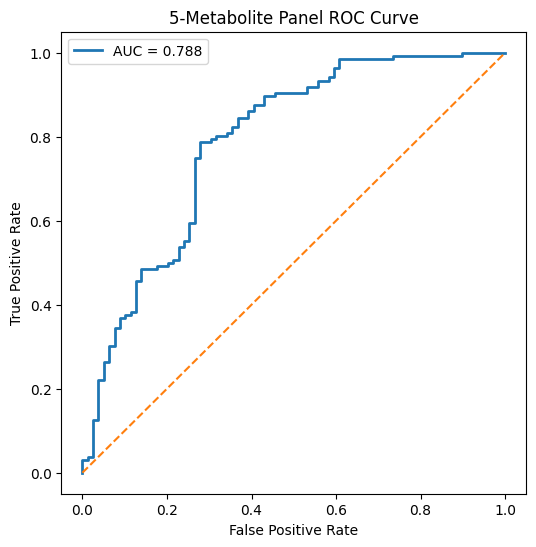

Cross-validated AUC: 0.7883469843633656


In [90]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

# Cross-validated probabilities
y_prob = cross_val_predict(
    model,
    X_all[panel_5],
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("5-Metabolite Panel ROC Curve")
plt.legend()
plt.show()

print("Cross-validated AUC:", roc_auc)

In [91]:
from sklearn.model_selection import cross_val_score

auc_scores = cross_val_score(
    model,
    X_all[panel_5],
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:", auc_scores)
print("Mean AUC:", auc_scores.mean())
print("Std AUC:", auc_scores.std())

Fold AUCs: [0.75952381 0.82407407 0.78703704 0.79861111 0.78240741]
Mean AUC: 0.7903306878306878
Std AUC: 0.021118104953355026


ValueError: at least one array or dtype is required